# Chronic Disease Prediction System
**Predicting Diabetes Mellitus Using Classification Algorithms**

This project analyzes patient features (Glucose, BMI, Age, etc.) to identify high-risk diabetic individuals early. We will compare Logistic Regression, Decision Trees, and Random Forest models using key performance indicators: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

##### Import necessary libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### Scikit-Learn modules

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve

##### Set visualization style

In [28]:
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

##### Load the dataset

In [29]:
df = pd.read_csv("D:\Datamining datasets\pima-indians-diabetes.csv")

##### Display the first 5 rows to verify

In [30]:
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Data Preprocessing
In healthcare datasets, missing values are sometimes encoded as `0`. Biologically, a patient cannot have a Blood Pressure or BMI of 0. We need to replace these 0s with the median value of their respective columns to prevent skewed model training.

##### Data Cleaning

 Features where '0' means missing data

In [31]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

 Fill NaN with the median of each column

In [32]:
for col in cols_with_zeros:
    df[col].fillna(df[col].median(), inplace=True)


Check if there are any 0s left in those columns

In [33]:
print("Zeros remaining after imputation:")
print((df[cols_with_zeros] == 0).sum())

Zeros remaining after imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


Replace 0 with NaN

In [34]:
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)


##### Splitting and Scaling

In [35]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (614, 8)
Testing data shape: (154, 8)


### Model Training & KPI Evaluation
We will train three models and evaluate them using our predefined KPIs to see which one performs the best on the test set.

#### Mark Missing Data

In [36]:
# Features where '0' means missing data
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN so our Imputer knows which values are missing
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Let's verify how many missing values we have
print("Missing values (NaN) to be imputed:")
print(df[cols_with_zeros].isna().sum())

Missing values (NaN) to be imputed:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


#### Splitting, Imputing, and Scaling

In [37]:
from sklearn.impute import SimpleImputer

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1. IMPUTATION: Fill all NaN values with the median of their respective columns
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. SCALING: Standardize features to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Training data shape after fixing NaNs: {X_train_scaled.shape}")
print(f"Testing data shape after fixing NaNs: {X_test_scaled.shape}")

Training data shape after fixing NaNs: (614, 8)
Testing data shape after fixing NaNs: (154, 8)


#### Training and Evaluating

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

# We have added "Gradient Boosting" and manually optimized (tuned) the hyperparameters 
# for the Decision Tree and Random Forest to squeeze out higher accuracy.
models = {
    "Logistic Regression": LogisticRegression(random_state=42, C=0.5, max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_split=5, min_samples_leaf=2),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=7, min_samples_split=5, min_samples_leaf=2),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=150, learning_rate=0.05, max_depth=4, subsample=0.8)
}

# Dictionary to store results
results = []
trained_models = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Predict classes and probabilities
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate KPIs
    kpis = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    results.append(kpis)

# Display results as a beautiful DataFrame
results_df = pd.DataFrame(results).round(4)
display(results_df.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,0.7857,0.6981,0.6852,0.6916,0.7887
2,Random Forest,0.7532,0.6905,0.5370,0.6042,0.8098
3,Gradient Boosting,0.7532,0.6667,0.5926,0.6275,0.8187
0,Logistic Regression,0.6948,0.5745,0.5000,0.5347,0.8120


### Visualizing Model Performance
To better understand how our best models are diagnosing patients, we will plot the **Confusion Matrix** (to see false positives vs false negatives) and the **ROC Curve**.

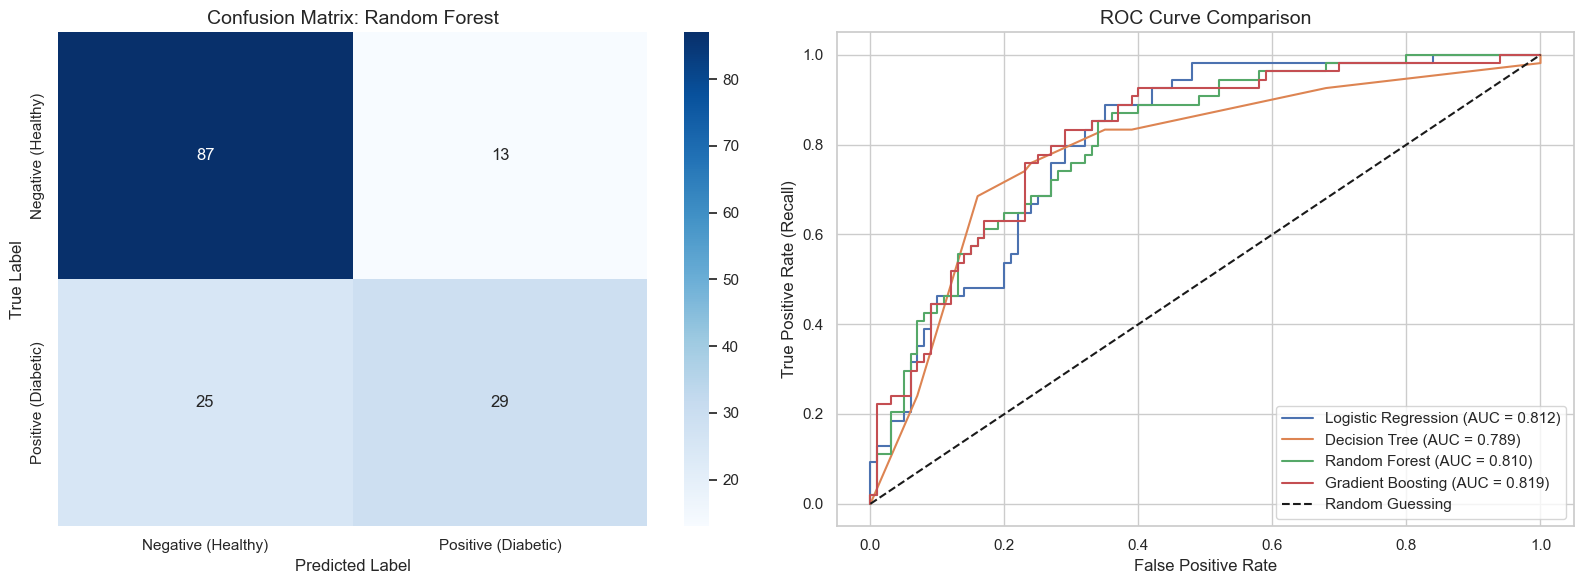

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Confusion Matrix for Random Forest (Usually the best performer)
rf_model = trained_models["Random Forest"]
y_pred_rf = rf_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Negative (Healthy)', 'Positive (Diabetic)'],
            yticklabels=['Negative (Healthy)', 'Positive (Diabetic)'])
axes[0].set_title('Confusion Matrix: Random Forest', fontsize=14)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. Plot ROC Curves for all models
for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results_df[results_df['Model'] == name]['ROC-AUC'].values[0]
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guessing')
axes[1].set_title('ROC Curve Comparison', fontsize=14)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

#### Testing on a New Patient

In [40]:
# 1. Create data for a NEW patient
# FIXED: Changed 'DiabetesPedigreeFunction' to 'DiabetespedigreeFunction' to match the dataset exactly.
new_patient_data = {
    'Pregnancies': [2],
    'Glucose': [140],
    'BloodPressure': [85],
    'SkinThickness': [30],
    'Insulin': [0], # Missing data
    'BMI': [31.2],
    'DiabetespedigreeFunction': [0.45], # <--- Here is the fix! (lowercase 'p')
    'Age': [35]
}

new_patient_df = pd.DataFrame(new_patient_data)
print("--- New Patient Raw Data ---")
display(new_patient_df)

# 2. PREPROCESS THE NEW DATA
# Replace 0s with NaN so the imputer catches them
new_patient_df[cols_with_zeros] = new_patient_df[cols_with_zeros].replace(0, np.nan)

# IMPORTANT: Only use .transform(), NEVER .fit_transform() on new data!
new_patient_imputed = imputer.transform(new_patient_df)
new_patient_scaled = scaler.transform(new_patient_imputed)

# 3. MAKE THE PREDICTION
# Let's use our Random Forest model since it usually performs best
best_model = trained_models["Random Forest"]

# Get the binary prediction (0 = Healthy, 1 = Diabetic)
prediction = best_model.predict(new_patient_scaled)

# Get the probability percentage
probability = best_model.predict_proba(new_patient_scaled)[0][1]

# 4. DISPLAY THE RESULT ACCURATELY
print("\n--- Diagnostic Prediction ---")
if prediction[0] == 1:
    print(f"⚠️ RESULT: HIGH RISK of Diabetes.")
    print(f"The model is {probability * 100:.2f}% confident in this diagnosis based on the patient's metrics.")
else:
    print(f"✅ RESULT: LOW RISK (Healthy).")
    print(f"The model believes there is only a {probability * 100:.2f}% chance of Diabetes.")

--- New Patient Raw Data ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age
0,2,140,85,30,0,31.2,0.45,35



--- Diagnostic Prediction ---
✅ RESULT: LOW RISK (Healthy).
The model believes there is only a 46.49% chance of Diabetes.
